<a href="https://colab.research.google.com/github/alkhurayjah/Task_DL/blob/main/Abdullah_Alkhurayjah_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

In [ ]:
import numpy as np

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

2. Load Dataset

In [ ]:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    "creditcard.csv"
)

/tmp/ipykernel_8115/3909799100.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [ ]:
# Quick preview
print(df.head())
print(df["Class"].value_counts())  # Check imbalance

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

3. Preprocessing

In [ ]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale features
scaler = StandardScaler()

# Fit
X_train = scaler.fit_transform(X_train)

# Transform
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

4. Handle Imbalance

In [ ]:
# Compute class weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

In [ ]:
# Simple ANN
model1 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Regularized ANN
model2 = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

In [ ]:
# =========================
# 3. Compile Models
# =========================
for model in [model1, model2]:
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

In [ ]:
# =========================
# 4. Early Stopping
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# =========================
# 5. Train Models
# =========================
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

In [ ]:
# =========================
# 6. Evaluation Function
# =========================
def evaluate_model(model, X_test, y_test, name, threshold=0.9):

    y_prob = model.predict(X_test)
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n====================================")
    print(f"{name} (Threshold={threshold})")
    print("====================================")

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("===== Model Performance =====")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1-Score   : {f1:.4f}")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    TN, FP, FN, TP = cm.ravel()

    print("\nDetailed Breakdown:")
    print(f"True Negatives  (TN): {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")
    print(f"True Positives  (TP): {TP}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return f1

In [ ]:
# =========================
# 7. Compare Models
# =========================
f1_model1 = evaluate_model(model1, X_test, y_test, "Simple ANN")
f1_model2 = evaluate_model(model2, X_test, y_test, "Regularized ANN")

# Best Model
if f1_model1 > f1_model2:
    best_model = model1
    best_name = "Simple ANN"
else:
    best_model = model2
    best_name = "Regularized ANN"

print("\n====================================")
print(f"🏆 BEST MODEL: {best_name}")
print("====================================")

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Simple ANN (Threshold=0.9)
===== Model Performance =====
Accuracy   : 0.9978
Precision  : 0.3750
Recall     : 0.9153
F1-Score   : 0.5320
ROC-AUC    : 0.9812

Confusion Matrix:
[[42573    90]
 [    5    54]]

Detailed Breakdown:
True Negatives  (TN): 42573
False Positives (FP): 90
False Negatives (FN): 5
True Positives  (TP): 54

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42663
           1       0.38      0.92      0.53        59

    accuracy                           1.00     42722
   macro avg       0.69      0.96      0.77     42722
weighted avg       1.00      1.00      1.00     42722

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Regularized ANN (Threshold=0.9)
===== Model Performance =====
Accuracy   : 0.9983
Precision  : 0.4463
Recall     : 0.9153
F1-Score   : 0.6000
ROC-AUC    : 0.9833

Confusion Matrix:
[[42596    67]
 [    5    54]]

Detailed Breakdown

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


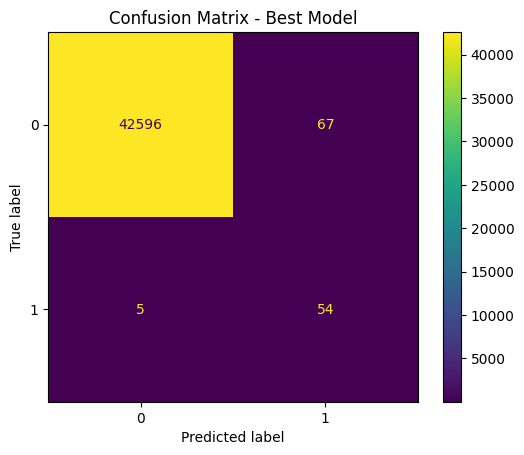

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_prob = best_model.predict(X_test)
y_pred = (y_prob >= 0.9).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Best Model")
plt.show()

The model successfully detected 54 out of 59 fraud cases with only 5 missed cases and a very low number of false positives (67), demonstrating strong performance in both detection and reliability.

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


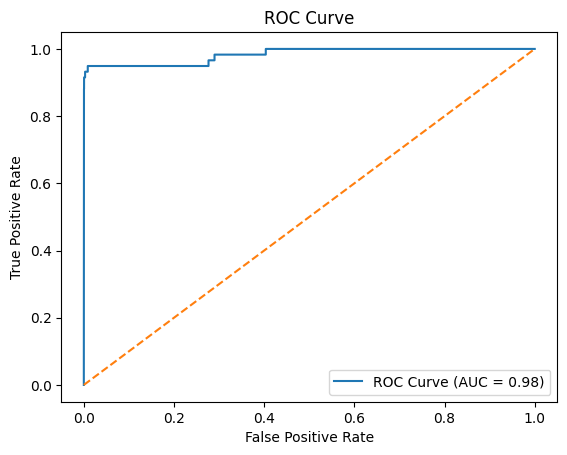

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

The ROC curve shows that the model achieves an AUC of 0.98, indicating excellent ability to distinguish between fraudulent and normal transactions.

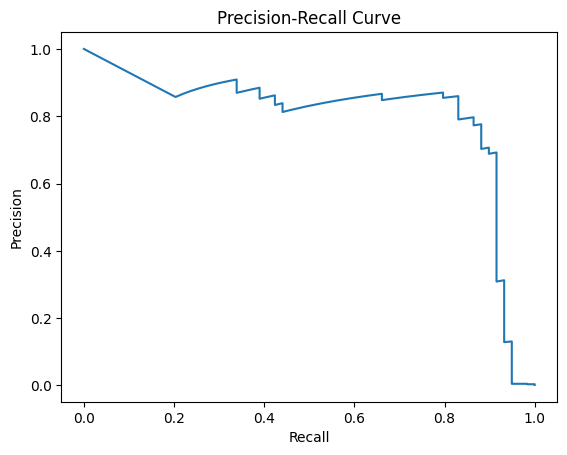

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall_vals, precision_vals)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

The Precision-Recall curve shows a strong trade-off between precision and recall. The model maintains high precision at high recall levels, which is crucial for imbalanced datasets like fraud detection.

In [ ]:
# =========================
# 8. Save Best Model
# =========================
best_model.save("best_model.keras")